# Week 3 · Task 3 — Monty Hall: simulate it, then solve it with Bayes

**Roadmap task:** *Simulate the Monty Hall problem, then solve it with Bayes. Both must agree.*

Plus the Week 3 "what you learn" item: **Bayes' theorem on a medical-test problem until the answer stops feeling wrong** (that is also Gate 1, question 3).

**What this notebook shows**

1. Deriving Bayes' theorem from the definition of conditional probability (two lines).
2. Warm-up: the medical-test base-rate problem, by formula, by counting, and by simulation.
3. Monty Hall by simulation (200,000 games).
4. Monty Hall by Bayes, step by step.
5. The twist that proves *why* it works: if the host opens a door **at random**, the answer changes to 50/50.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction as F

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(2026)

## 1. Deriving Bayes' theorem

Conditional probability is *defined* as "restrict to the cases where $B$ happened, and ask what fraction of those also have $A$":

$$P(A\mid B) = \frac{P(A \cap B)}{P(B)}$$

The same logic the other way round gives $P(B\mid A) = \dfrac{P(A\cap B)}{P(A)}$, so $P(A\cap B) = P(B\mid A)\,P(A)$. Substitute:

$$\boxed{P(A\mid B) = \frac{P(B\mid A)\,P(A)}{P(B)}}\qquad\text{with}\qquad P(B) = \sum_{\text{all } a} P(B\mid a)\,P(a)$$

The bottom line is the **law of total probability**: add up every way $B$ could happen.

**In simple words:** *posterior = likelihood × prior, then rescale so everything adds to 1.*

| name | symbol | meaning |
|---|---|---|
| prior | $P(A)$ | what you believed before the evidence |
| likelihood | $P(B\mid A)$ | how expected the evidence is, **if** $A$ were true |
| evidence | $P(B)$ | how expected the evidence is overall |
| posterior | $P(A\mid B)$ | what you should believe after the evidence |

## 2. Warm-up: the medical test (a base-rate problem)

A disease affects **1 in 100** people. A test catches **95%** of sick people (sensitivity) and wrongly flags **5%** of healthy people (false-positive rate). You test positive. How likely is it that you are sick?

Most people (including many doctors, in published studies) say about 95%. Bayes:

$$P(\text{sick}\mid +) = \frac{0.95 \times 0.01}{0.95\times 0.01 + 0.05 \times 0.99} = \frac{0.0095}{0.0095 + 0.0495} = \frac{0.0095}{0.059} \approx 16\%$$

In [2]:
prior, sens, fpr = F(1, 100), F(95, 100), F(5, 100)
posterior = sens * prior / (sens * prior + fpr * (1 - prior))
print(f"Bayes, exact: P(sick | +) = {posterior} ≈ {float(posterior):.4f}")

# The same thing by COUNTING 10,000 people - the version that makes it stop feeling wrong
people = 10_000
sick = people * prior; healthy = people - sick
true_pos = sick * sens; false_pos = healthy * fpr
print(f"\nOut of {people:,} people: {int(sick)} sick, {int(healthy)} healthy")
print(f"  positives from sick people   : {float(true_pos):.0f}")
print(f"  positives from healthy people: {float(false_pos):.0f}   <- the healthy group is so big that 5% of it swamps the sick")
print(f"  P(sick | +) = {float(true_pos):.0f} / {float(true_pos + false_pos):.0f} = {float(true_pos / (true_pos + false_pos)):.4f}")

# And by simulation
N = 1_000_000
is_sick = rng.random(N) < float(prior)
positive = np.where(is_sick, rng.random(N) < float(sens), rng.random(N) < float(fpr))
print(f"\nsimulation of {N:,} people: P(sick | +) ≈ {is_sick[positive].mean():.4f}")

Bayes, exact: P(sick | +) = 19/118 ≈ 0.1610

Out of 10,000 people: 100 sick, 9900 healthy
  positives from sick people   : 95
  positives from healthy people: 495   <- the healthy group is so big that 5% of it swamps the sick
  P(sick | +) = 95 / 590 = 0.1610

simulation of 1,000,000 people: P(sick | +) ≈ 0.1615


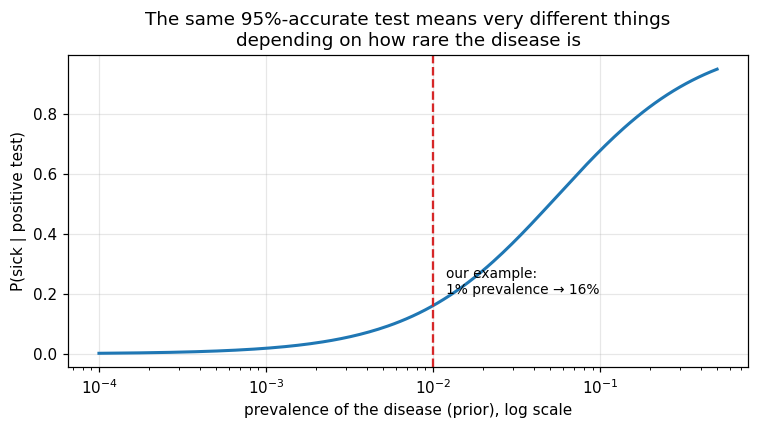

In [3]:
priors = np.logspace(-4, -0.3, 200)
post = 0.95 * priors / (0.95 * priors + 0.05 * (1 - priors))
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(priors, post, lw=2)
ax.axvline(0.01, color="tab:red", ls="--"); ax.annotate("our example:\n1% prevalence → 16%", (0.012, 0.2), fontsize=9)
ax.set_xlabel("prevalence of the disease (prior), log scale"); ax.set_ylabel("P(sick | positive test)")
ax.set_title("The same 95%-accurate test means very different things\ndepending on how rare the disease is")
fig.tight_layout(); fig.savefig(FIG / "w3_base_rate.png", dpi=150); plt.show()

**The lesson (base-rate neglect):** a test's accuracy is not the probability you're sick. The prior matters enormously. This is *the same maths* as a fraud model flagging transactions when fraud is 0.1% of traffic — most flags will be false alarms (Week 12: precision vs recall).

## 3. Monty Hall — by simulation

Three doors. One car, two goats. You pick a door. The host, **who knows where the car is**, opens one of the *other* doors that has a goat, and offers you a switch. Stay or switch?

In [4]:
def monty_hall(n_games, n_doors=3, host_knows=True, rng=rng):
    """Simulate games. Returns (P(win | stay), P(win | switch)), counting only valid games.

    host_knows=False: the host opens a random other door; games where he accidentally
    reveals the car are thrown away (we only look at games that LOOK like the real show).
    """
    car = rng.integers(0, n_doors, n_games)
    pick = rng.integers(0, n_doors, n_games)
    stay_wins, switch_wins, valid = 0, 0, 0
    for c, p in zip(car, pick):
        others = [d for d in range(n_doors) if d != p]
        if host_knows:
            goat_doors = [d for d in others if d != c]
            opened = set(rng.choice(goat_doors, size=n_doors - 2, replace=False))
        else:
            opened = set(rng.choice(others, size=n_doors - 2, replace=False))
            if c in opened:
                continue                       # car revealed - not a "normal-looking" game
        valid += 1
        remaining = [d for d in others if d not in opened][0]   # the one door you could switch to
        stay_wins += (p == c)
        switch_wins += (remaining == c)
    return stay_wins / valid, switch_wins / valid

stay, switch = monty_hall(200_000)
print(f"simulation, 200,000 games:  P(win | stay) = {stay:.4f}   P(win | switch) = {switch:.4f}")

simulation, 200,000 games:  P(win | stay) = 0.3341   P(win | switch) = 0.6659


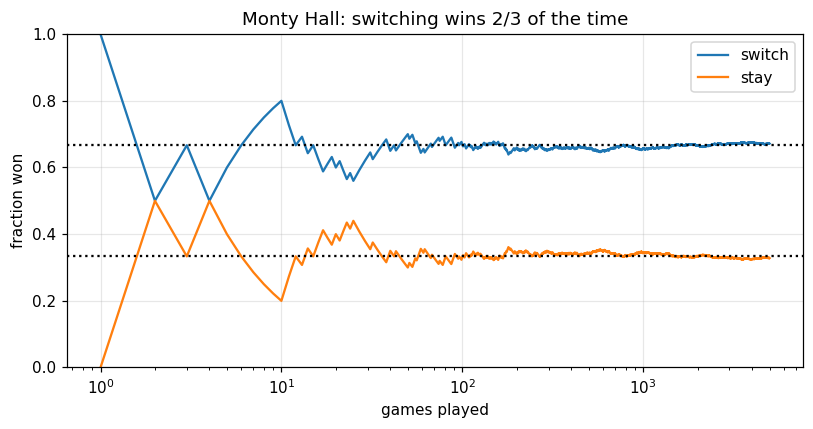

In [5]:
# Watch the estimate settle as games accumulate
car = rng.integers(0, 3, 5000); pick = rng.integers(0, 3, 5000)
switch_win = (car != pick)                   # with a knowing host, switching wins exactly when your first pick was wrong
games = np.arange(1, 5001)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(games, np.cumsum(switch_win) / games, label="switch")
ax.plot(games, np.cumsum(~switch_win) / games, label="stay")
ax.axhline(2 / 3, color="k", ls=":"); ax.axhline(1 / 3, color="k", ls=":")
ax.set_xscale("log"); ax.set_ylim(0, 1); ax.set_xlabel("games played"); ax.set_ylabel("fraction won")
ax.set_title("Monty Hall: switching wins 2/3 of the time"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "w3_monty_hall.png", dpi=150); plt.show()

Notice the comment in that cell: **with a knowing host, switching wins exactly when your first pick was wrong** — and your first pick is wrong 2/3 of the time. That's the one-line intuition.

## 4. Monty Hall — by Bayes

Say you picked **door 1** and the host opened **door 3**. Let $C_i$ = "car behind door $i$", and $H_3$ = "host opens door 3".

**Prior:** $P(C_1) = P(C_2) = P(C_3) = \tfrac13$.

**Likelihood** — how likely is the host to open door 3 in each world? *This is where the host's knowledge enters.*

| world | host's options (can't open your door 1 or the car) | $P(H_3 \mid C_i)$ |
|---|---|---|
| car behind 1 | door 2 or door 3, picks at random | $\tfrac12$ |
| car behind 2 | **must** open door 3 | $1$ |
| car behind 3 | would never open door 3 | $0$ |

**Evidence:** $P(H_3) = \tfrac12\cdot\tfrac13 + 1\cdot\tfrac13 + 0\cdot\tfrac13 = \tfrac12$

**Posterior:**

$$P(C_1\mid H_3) = \frac{\tfrac12\cdot\tfrac13}{\tfrac12} = \frac13 \qquad P(C_2\mid H_3) = \frac{1\cdot\tfrac13}{\tfrac12} = \frac23 \qquad P(C_3\mid H_3) = 0$$

Now in code, with exact fractions, as a tiny reusable Bayes calculator:

In [6]:
def bayes_table(prior, likelihood):
    """prior, likelihood: dicts world -> probability. Returns the posterior dict."""
    joint = {w: prior[w] * likelihood[w] for w in prior}
    evidence = sum(joint.values())
    for w in prior:
        print(f"  {w:<14}  prior {str(prior[w]):>4}  × likelihood {str(likelihood[w]):>4}"
              f"  = {str(joint[w]):>4}   → posterior {str(joint[w] / evidence):>4}")
    print(f"  evidence P(host opens door 3) = {evidence}")
    return {w: joint[w] / evidence for w in prior}

print("KNOWING host:")
post = bayes_table(prior={"car behind 1": F(1, 3), "car behind 2": F(1, 3), "car behind 3": F(1, 3)},
                   likelihood={"car behind 1": F(1, 2), "car behind 2": F(1), "car behind 3": F(0)})
print(f"\nBayes:      P(win | stay) = {post['car behind 1']}   P(win | switch) = {post['car behind 2']}")
agree = abs(stay - 1/3) < 0.01 and abs(switch - 2/3) < 0.01
print(f"Simulation: P(win | stay) = {stay:.4f}  P(win | switch) = {switch:.4f}   agree within 0.01? {agree}")

KNOWING host:
  car behind 1    prior  1/3  × likelihood  1/2  =  1/6   → posterior  1/3
  car behind 2    prior  1/3  × likelihood    1  =  1/3   → posterior  2/3
  car behind 3    prior  1/3  × likelihood    0  =    0   → posterior    0
  evidence P(host opens door 3) = 1/2

Bayes:      P(win | stay) = 1/3   P(win | switch) = 2/3
Simulation: P(win | stay) = 0.3341  P(win | switch) = 0.6659   agree within 0.01? True


## 5. The twist that proves you understand it — a host who *doesn't* know

Suppose the host opens one of the other two doors **at random**, and it *happens* to show a goat. Should you switch now?

Only the likelihood changes. If the car is behind door 2, a random host opens door 3 only half the time (he might have opened door 2 and shown the car):

| world | $P(\text{host opens 3 and shows a goat} \mid C_i)$ |
|---|---|
| car behind 1 | $\tfrac12$ |
| car behind 2 | $\tfrac12$ (not 1 any more!) |
| car behind 3 | $0$ (it would have shown the car) |

In [7]:
print("RANDOM host (who happened to show a goat):")
post_random = bayes_table(prior={"car behind 1": F(1, 3), "car behind 2": F(1, 3), "car behind 3": F(1, 3)},
                          likelihood={"car behind 1": F(1, 2), "car behind 2": F(1, 2), "car behind 3": F(0)})
stay_r, switch_r = monty_hall(200_000, host_knows=False)
print(f"\nBayes:      stay {post_random['car behind 1']}  switch {post_random['car behind 2']}")
agree = abs(stay_r - 0.5) < 0.01 and abs(switch_r - 0.5) < 0.01
print(f"Simulation: stay {stay_r:.4f}  switch {switch_r:.4f}   agree within 0.01? {agree}  — now it's 50/50")

RANDOM host (who happened to show a goat):
  car behind 1    prior  1/3  × likelihood  1/2  =  1/6   → posterior  1/2
  car behind 2    prior  1/3  × likelihood  1/2  =  1/6   → posterior  1/2
  car behind 3    prior  1/3  × likelihood    0  =    0   → posterior    0
  evidence P(host opens door 3) = 1/3



Bayes:      stay 1/2  switch 1/2
Simulation: stay 0.4980  switch 0.5020   agree within 0.01? True  — now it's 50/50


**This is the real lesson of Monty Hall:** the *same observation* (a goat behind door 3) carries different information depending on the **process that generated it**. A knowing host is forced to avoid the car, so his choice leaks information about where the car is. In Bayes' theorem, that process lives entirely in the **likelihood**. In data science, the same thing happens whenever data is *selected* by some process (survivorship bias, missing-not-at-random data in Week 6) — you must model how the data came to be in front of you.

## 6. Bonus — 100 doors

With 100 doors, you pick one and a knowing host opens 98 goat doors. Switching wins 99/100. It's the same logic, and it makes the intuition obvious:

In [8]:
stay100, switch100 = monty_hall(20_000, n_doors=100)
print(f"100 doors: P(win | stay) ≈ {stay100:.3f}   P(win | switch) ≈ {switch100:.3f}")

100 doors: P(win | stay) ≈ 0.010   P(win | switch) ≈ 0.990


## 7. Your turn (Gate 1 practice)

1. **Base-rate problem:** 0.5% of emails in a company are phishing. A filter catches 98% of phishing and wrongly flags 2% of normal emails. An email is flagged. What's the probability it's phishing? Do it on paper, then by counting 100,000 emails, then check in code. *(Answer ≈ 19.8%.)*
2. You take the medical test **twice** and both are positive (assume independent errors). Use the first posterior (16%) as the new prior. What is $P(\text{sick})$ now?
3. **Derive Bayes' theorem on a blank page** from $P(A\mid B) = P(A\cap B)/P(B)$ in under 2 minutes.
4. **Explain out loud:** "In Monty Hall, why does it matter whether the host knows where the car is?"